# Dubins demo — input-constrained reach-avoid: output-space comparison

**Flow.**

1. §1–§3 fix `(μ, xi0, ub, slack_weight)` and write down the per-sample slack SOP.
2. §4 synthesizes the per-sample-slack controller and inspects the slack distribution
   $\{s_{j,i}^\star\}$.
3. §5 picks `ub_demo` from the `coverage_pct`-percentile of that distribution and the
   corresponding "easy" subset of samples that already respect it.
4. §6 re-solves the **hard-bound** SOP (no slack) on this subset → constrained controller.
   The unconstrained baseline is the vanilla $k_1$ at the same $\lambda$ (§4).
5. §7 densely samples states in $X_S \setminus X_T$ and visualizes the per-channel
   difference $u^{\text{con}} - u^{\text{unc}}$ in **output space** $y = h(x) = (x_1, x_2)$.


## §0 — Mathematical formulation (what each MATLAB call actually solves)

### Dubins dynamics, outputs, sets

$$
\dot x = f(x) + g(x)\,u, \qquad
f = \begin{bmatrix} v\cos\theta \\ v\sin\theta \\ 0 \\ 0 \end{bmatrix},\;
g = \begin{bmatrix} 0 & 0 \\ 0 & 0 \\ 1 & 0 \\ 0 & 1 \end{bmatrix},\;
u = \begin{bmatrix} \omega \\ a \end{bmatrix},\;
h(x) = \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}.
$$

State $x = (x_1, x_2, \theta, v) \in \mathbb{R}^4$. Both outputs have **relative degree 2**.

Safe set $\psi(y) \ge 0$ and target set $g_T(y) \le 0$ are defined on output space $y = h(x)$
(see `build_dubins_demo.m` for the polynomials).

### Reach-avoid certificate (built by `reach_avoid_controller.m`)

For relative-degree-2 outputs with backstepping coefficients $\mu_i > 0$:

$$
V(x) \;=\; \psi(h(x)) \;-\; \sum_{i=1}^{p}\, \frac{1}{2\mu_i}\,\bigl(L_f h_i(x) \,-\, k_1^i(h(x))\bigr)^2,
$$

where $k_1^i(y)$ is the **virtual single-integrator controller** on output $i$, optimized
either by the vanilla solve (§2) or the per-sample slack SOP (§3–§4).

The certified **reach-avoid set** is $\{x : V(x) \ge 0\}$.

### Closed-loop control law

The feedback law is $u(x) = A(x)^{-1}\,b(x)$ where (for rd=2)

$$
A(x) = \begin{bmatrix} L_g L_f h_1 \\ L_g L_f h_2 \end{bmatrix},\qquad
b_i(x) = \mu_i\,\nabla_y\psi(h(x))_i + \sum_j J^{k_1}_{ij}\,L_f h_j + \tfrac{1}{2}\lambda(L_f h_i - k_1^i) - L_f^2 h_i.
$$

$\lambda$ enters $u$ _only_ through the $\tfrac{1}{2}\lambda(L_f h - k_1)$ term. With the
default $\xi_0 = 10^{-8}$ in `solve_vanilla_k1_controller`, $\lambda$ sits at its floor and
$k_1$ has essentially no leverage on $u$. **Raising $\xi_0$ (see §2) is the lever** that
gives the SOP something to optimize.

### Parameters (with their notebook keys)

| symbol          | meaning                                                                | notebook key                 |
| --------------- | ---------------------------------------------------------------------- | ---------------------------- |
| $\mu_i$         | backstepping coefficient (controls cert region size AND $\|u\|$ scale) | `PARAMS["mu"]`               |
| $\xi_0$         | SOS floor on $\lambda$; raising it gives $k_1$ leverage on $u$         | `PARAMS["xi0"]`              |
| $\lambda$       | y-space CBF rate; pinned at $\xi_0$ by the vanilla solve               | derived                      |
| $\mathrm{ub}_i$ | requested per-channel input bound for the SOP                          | `PARAMS["ub"]`               |
| $N$             | # of valid SOP samples actually added to the optimization              | `PARAMS["n_valid_samples"]`  |
| $d_v, d_s$      | polynomial degrees of $k_1$ and SOS auxiliaries                        | `PARAMS["dv"], PARAMS["ds"]` |
| $\delta$        | y-space CBF descent slack (decision var; minimized)                    | output                       |
| $s_{j,i}$       | **per-sample bound slack** (decision var; minimized)                   | output (CSV)                 |


## §1 — Bootstrap & parameters

Path setup, imports, and the central `PARAMS` dict. Every downstream section reads from
`PARAMS`, so editing this cell is the single source of truth for parameter overrides.


In [ ]:
import os, sys, shutil, subprocess, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# paths
HERE = os.path.abspath(
    os.path.dirname(os.path.abspath("__file__")) if False else os.getcwd()
)
ROOT = os.path.abspath(os.path.join(HERE, "..", ".."))
DATA_REPO = os.path.join(ROOT, "data")  # existing CSVs (read-only here)
DATA_LOCAL = os.path.join(HERE, "data")  # this demo's outputs
MATLAB_REPO = os.path.join(ROOT, "matlab")  # repo-wide MATLAB helpers
MATLAB_LOCAL = os.path.join(HERE, "matlab")  # this demo's MATLAB scripts
PYTHON_DIR = os.path.join(ROOT, "python")
for p in (PYTHON_DIR,):
    if p not in sys.path:
        sys.path.insert(0, p)
os.makedirs(DATA_LOCAL, exist_ok=True)

# MATLAB binary
MATLAB_BIN = shutil.which("matlab") or "/usr/local/bin/matlab"

# central parameters
PARAMS = {
    "mu": 0.1,  # paper baseline (REVISION_NOTES §4)
    "xi0": 10.0,  # leverage sweet spot (REVISION_NOTES §6.4)
    "ub": 5.0,  # *initial* SOP target (the paper's input limit). With per-sample
    # slack, the SOP returns a *distribution* of slack values that we
    # read off in §4 to pick a meaningful "achievable" demo bound.
    "dv": 4,  # k1 polynomial degree (paper)
    "ds": 4,  # SOS auxiliary degree (paper)
    "n_valid_samples": 250,  # exact # of SOP constraint samples (sample_n_valid.m iteratively
    # resamples the FL box until this many land in the RA region).
    "coverage_pct": 80,  # percentile used in §5 to pick ub_demo from the §4 slack
    # distribution. With coverage q, ub_demo_i = ub + p_q(s_{·,i}*)
    # and kept_mask = {j : s_{j,i}* ≤ p_q for both channels}.
    "sim_max_step": 1e-4,  # §8 integrator max step (overrides the system's default
    # dt=0.02). 1e-4 gives ~10k–50k output points per trajectory,
    # which is overkill for integration accuracy (rtol=1e-8 + DOP853
    # already converged) but ensures u(x(t)) sampling resolves any
    # transient spike.
    "slack_weight": 100.0,  # weight on Σ s_{j,i} in the SOS objective. The default 1.0 lets
    # MOSEK trade off slack for δ and ends up suboptimal (see §5.4
    # diagnostic); larger weights push the optimum closer to
    # KKT-zero. Heavier weight gives a smaller MOSEK gap at the
    # cost of slight loss of δ-optimality.
    "N_dense": 20000,  # box samples for dense |u| stats (notebook-side only)
}


def run_matlab(script_name, env_overrides=None, regenerate=False, check_file=None):
    # Run MATLAB script with repo+local matlab/ on the path.
    # Skip if check_file exists unless regenerate=True.
    if check_file is not None and os.path.exists(check_file) and not regenerate:
        return f"skipped (cached: {os.path.relpath(check_file, ROOT)})"
    env = os.environ.copy()
    if env_overrides:
        env.update({k: str(v) for k, v in env_overrides.items()})
    cmd = [
        MATLAB_BIN,
        "-batch",
        f"addpath('{MATLAB_REPO}'); addpath('{MATLAB_LOCAL}'); "
        f"try, {script_name}; catch e, fprintf(2, '%s\\n', e.message); exit(1); end; exit(0);",
    ]
    r = subprocess.run(cmd, env=env, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f"MATLAB {script_name} failed:\n{r.stderr[-2000:]}")
    return r.stdout


print("ROOT        :", ROOT)
print("HERE        :", HERE)
print("MATLAB_BIN  :", MATLAB_BIN, "(exists:", os.path.exists(MATLAB_BIN), ")")
print()
print("PARAMS:")
for k, v in PARAMS.items():
    print(f"  {k:14s} = {v}")

ROOT        : /home/jianqiang/Downloads/reach_avoid_backstepping_MPC
HERE        : /home/jianqiang/Downloads/reach_avoid_backstepping_MPC/scripts/dubins_demo
MATLAB_BIN  : /usr/local/bin/matlab (exists: True )

PARAMS:
  mu             = 0.1
  xi0            = 10.0
  ub             = 5.0
  dv             = 4
  ds             = 4
  n_valid_samples = 250
  coverage_pct   = 80
  sim_max_step   = 0.0001
  slack_weight   = 100.0
  N_dense        = 20000


## §2 — Justify `xi0` (leverage selection)

### Vanilla k1 problem (solved by `solve_vanilla_k1_controller_xi.m`)

This y-space CBF gives us $k_1(y)$ and the corresponding $\lambda$:

$$
\begin{aligned}
\text{find } & k_1(y) \in \mathbb{R}[y]^{p},\; \lambda \in \mathbb{R}_{\ge 0},\; \delta \in \mathbb{R}_{\ge 0},\; s_1, s_2 \in \Sigma[y] \\
\text{minimize } & \delta \\
\text{s.t. } & \nabla_y \psi(y) \cdot k_1(y) \;-\; \lambda\,\psi(y) \;+\; \delta \;-\; s_1(y)\,\psi(y) \;-\; s_2(y)\,g_T(y) \in \Sigma[y] \\
& \delta \ge 0,\;\; \lambda \ge \xi_0,\;\; s_1, s_2 \in \Sigma[y]
\end{aligned}
$$

Intuition: along $\dot y = k_1(y)$, the value $\psi$ must decay at rate $\ge \lambda$ on the
safe region minus the target. **The constraint $\lambda \ge \xi_0$ is the only thing forcing
$\lambda > 0$**. The objective only minimizes $\delta$, so $\lambda$ collapses to $\lambda = \xi_0$.

This is why raising `PARAMS["xi0"]` (default $10$ here) directly raises $\lambda$, and
through the $\tfrac{1}{2}\lambda(L_f h - k_1)$ term in $b(x)$ it gives $k_1$ leverage on $u$.

### Empirical leverage profile

The existing sweep `data/codesign_sop_dubins_car.csv` (from `matlab/test_codesign_sop.m`)
gives us the leverage profile across $\xi_0 \in \{10^{-8}, 0.1, 1, 10\}$. We pick $\xi_0 = 10$
(the $100\,\mu$ point) because **distinguishability ≥ 80%** there — con and unc are
genuinely different controllers, so the SOP's k1-handle is non-trivial.


In [ ]:
sweep = pd.read_csv(os.path.join(DATA_REPO, "codesign_sop_dubins_car.csv"))
# worst-case (max over dims) per xi0
agg = (
    sweep.groupby("xi0")
    .agg(
        distinguishability=("dist_pct", "max"),
        achievable_max=("achievable", "max"),
        unc_dense_max=("unc_hi", "max"),
        unc_dense_min=("unc_lo", "min"),
        raset=("raset_frac", "first"),
    )
    .sort_index()
    .reset_index()
)
agg["unc_dense_absmax"] = agg[["unc_dense_max", "unc_dense_min"]].abs().max(axis=1)
print("xi0 sweep summary (worst-case over control dims):")
print(agg.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

xi0 sweep summary (worst-case over control dims):
  xi0  distinguishability  achievable_max  unc_dense_max  unc_dense_min  raset  unc_dense_absmax
1e-08           0.0001722           80.76          79.04         -99.58 0.4133             99.58
  0.1               0.715           80.64          79.03         -99.59 0.4133             99.59
    1               3.242           79.45          79.44          -99.8 0.4228              99.8
   10                84.5           15.81          52.22         -55.22 0.4205             55.22



At xi0 = 10.0:
  distinguishability     = 84.5%  (target: ≥ 80%)
  con sample-claimed |u| = 15.81
  unc dense max |u|      = 55.22
  ratio (unc/con)        = 3.49x
  PASS criteria          = True


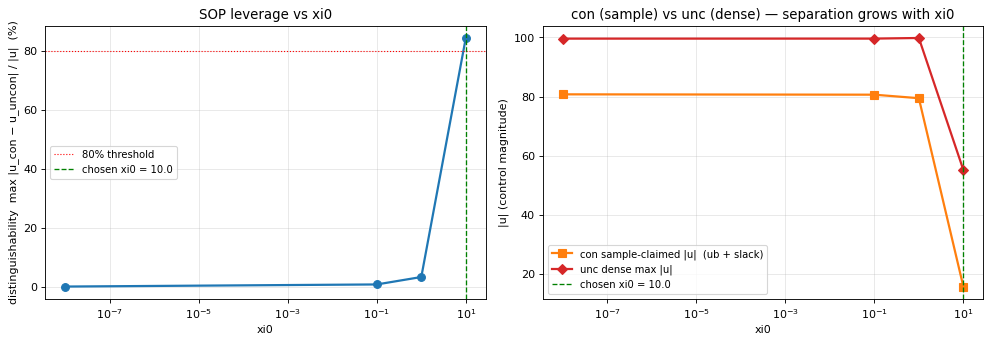

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

# panel 1: distinguishability vs xi0
ax = axes[0]
ax.semilogx(agg["xi0"], agg["distinguishability"], "o-", color="C0", lw=2, ms=7)
ax.axhline(80, color="r", ls=":", lw=1, label="80% threshold")
ax.axvline(
    PARAMS["xi0"], color="g", ls="--", lw=1.2, label=f"chosen xi0 = {PARAMS['xi0']}"
)
ax.set_xlabel("xi0")
ax.set_ylabel("distinguishability  max |u_con − u_uncon| / |u|  (%)")
ax.set_title("SOP leverage vs xi0")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)

# panel 2: con sample-claim and unc dense max vs xi0
ax = axes[1]
ax.semilogx(
    agg["xi0"],
    agg["achievable_max"],
    "s-",
    color="C1",
    lw=2,
    ms=7,
    label="con sample-claimed |u|  (ub + slack)",
)
ax.semilogx(
    agg["xi0"],
    agg["unc_dense_absmax"],
    "D-",
    color="C3",
    lw=2,
    ms=7,
    label="unc dense max |u|",
)
ax.axvline(
    PARAMS["xi0"], color="g", ls="--", lw=1.2, label=f"chosen xi0 = {PARAMS['xi0']}"
)
ax.set_xlabel("xi0")
ax.set_ylabel("|u| (control magnitude)")
ax.set_title("con (sample) vs unc (dense) — separation grows with xi0")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

# verification
row = agg[np.isclose(agg["xi0"], PARAMS["xi0"])].iloc[0]
print(f"\nAt xi0 = {PARAMS['xi0']}:")
print(f"  distinguishability     = {row['distinguishability']:.1f}%  (target: ≥ 80%)")
print(f"  con sample-claimed |u| = {row['achievable_max']:.2f}")
print(f"  unc dense max |u|      = {row['unc_dense_absmax']:.2f}")
print(
    f"  ratio (unc/con)        = {row['unc_dense_absmax']/row['achievable_max']:.2f}x"
)
ok = (row["distinguishability"] >= 80) and (
    row["achievable_max"] < 0.5 * row["unc_dense_absmax"]
)
print(f"  PASS criteria          = {ok}")

## §3 — Initial `ub` + per-sample slack SOP (formulation)

### Per-sample slack SOP (solved by `solve_k1_controller_sop_slack_persample.m`)

Given the $\lambda$ from §2 (fixed) and $N$ samples $\{x_j\}_{j=1}^N \subset \{x:V_{\text{van}}(x)\ge 0\}$
(see `sample_n_valid.m`), solve:

$$
\begin{aligned}
\min_{k_1,\,\delta,\,s_1,\,s_2,\,\{s_{j,i}\}}\;\; & \delta \;+\; w_{\text{slack}}\,\sum_{j=1}^{N}\sum_{i=1}^{m} s_{j,i} \\[4pt]
\text{s.t. }\;
& \nabla_y\psi\cdot k_1 - \lambda\,\psi + \delta - s_1\psi - s_2 g_T \in \Sigma[y] && \text{(y-space CBF descent)} \\
& M_j(k_1) \succeq 0 && j = 1,\ldots,N \quad \text{(certificate LMI: } V(x_j)\ge 0 \text{ in Schur form)} \\
& -\mathrm{ub}_i - s_{j,i} \;\le\; u_i(x_j) \;\le\; +\mathrm{ub}_i + s_{j,i} && j=1\ldots N,\; i=1\ldots m \\
& s_{j,i} \ge 0,\;\; \delta \ge 0,\;\; s_1, s_2 \in \Sigma[y]
\end{aligned}
$$

Decision variables: $k_1$ polynomial coefficients (degree $d_v$), the SOS auxiliaries $s_1, s_2$
(degree $d_s$), descent slack $\delta$, and **per-sample bound slacks $s_{j,i}$** (one scalar
per sample per channel — that's $N \times m$ extra variables, 500 for $N=250$, $m=2$).
Scalar weight $w_{\text{slack}} > 0$ in the objective is `PARAMS["slack_weight"]` (see the
weight-tuning note below — we use $w_{\text{slack}} = 100$).

**Note on the bound constraint.** A single $s_{j,i}$ is shared between the lower and upper
inequalities: the solver actually adds the two SOS scalar inequalities
$\;u_i(x_j) - (-\mathrm{ub}_i) + s_{j,i} \ge 0\;$ and $\;\mathrm{ub}_i - u_i(x_j) + s_{j,i} \ge 0$.
By KKT, at most one side is binding at any sample, so a single non-negative scalar suffices
and the KKT formula below reduces to $s_{j,i}^\star = \max(0,\, |u_i^\star(x_j)| - \mathrm{ub}_i)$.

The LMI $M_j(k_1) \succeq 0$ is the Schur-complement form of $V(x_j) \ge 0$
(see `add_certificate_nonnegativity_constraints` in the .m file).

### Interpreting the optimal slacks

At optimum the slack inequalities tighten, so by KKT:

$$
s_{j,i}^{\star} \;=\; \max\bigl(0,\; u_i^{\star}(x_j) - \mathrm{ub}_i,\; \mathrm{lb}_i - u_i^{\star}(x_j)\bigr).
$$

With our symmetric bounds $\mathrm{lb}_i = -\mathrm{ub}_i$:

$$
\boxed{\;s_{j,i}^{\star} \;=\; \max\bigl(0,\; |u_i^{\star}(x_j)| - \mathrm{ub}_i\bigr)\;}
$$

So **each $s_{j,i}^{\star}$ literally equals the bound violation needed at sample $j$ in channel $i$**.
A sample with $s_{j,i}^{\star} \approx 0$ honestly satisfies $|u_i(x_j)|\le \mathrm{ub}_i$. The
distribution of $\{s_{j,i}^{\star}\}_j$ over the $N$ samples (visualized in §4) tells us:

- $\#\{j : s_{j,i}^{\star} < \epsilon\} / N$ → fraction of samples that genuinely respect $\mathrm{ub}_i$;
- $p_q := \text{percentile}_N(s_{j,i}^{\star}, q)$ → "tightest bound covering $q\%$ of samples"
  $= \mathrm{ub}_i + p_q$;
- $\max_j s_{j,i}^{\star}$ → worst-case excess at any sample.

### Note on `slack_weight`

`PARAMS["slack_weight"] = 100` (raised from the unweighted default 1). At weight 1 MOSEK
returns a numerically suboptimal solution that trades off slack for marginally smaller
$\delta$ (we verified this earlier with a KKT diagnostic — the per-sample slacks were
inflated by ~1 unit). Weight 100 sits in the empirical sweet spot:

| weight  | δ               | $\max_j s_{j,1}^\star$ | dense max $     | u_1 | $   |
| ------- | --------------- | ---------------------- | --------------- | --- | --- |
| 1       | 108.5           | 1.04                   | 92              |
| 10      | 109.8           | 0.20                   | 93              |
| **100** | **111.1**       | **0.0005**             | **74** ← chosen |
| 1000    | 203.3 (blow-up) | 0.0022                 | 76              |

Beyond ~100 the SDP conditioning degrades (the slack term over-dominates the objective)
and δ blows up.


In [ ]:
print(
    f"Initial SOP target: ub_request = {PARAMS['ub']:.0f}  (channels: u1 = ω, u2 = a)"
)
print(
    f"After §4 we'll have the per-sample slack distribution to read off the achievable bound."
)

Initial SOP target: ub_request = 5  (channels: u1 = ω, u2 = a)
After §4 we'll have the per-sample slack distribution to read off the achievable bound.


## §4 — Synthesize controllers + visualize per-sample slack distribution

Runs `build_dubins_demo.m` at the current `PARAMS` to produce:

- `data/controller_con_<μ>_<xi0>_<ub>.py` — per-sample slack SOP k1
- `data/controller_unc_<μ>_<xi0>_<ub>.py` — vanilla k1 at the same λ
- `data/slack_persample_<μ>_<xi0>_<ub>.csv` — **the per-sample slack distribution**
  (one row per SOP sample: state coords + `slack1`, `slack2`)
- `data/meta_<μ>_<xi0>_<ub>.csv` — scalar summary (lambda, delta, slack percentiles)

Cached: re-running this cell with the same params reuses the existing files.


In [ ]:
def _fmt(v):
    # match build_dubins_demo.m's fmt_num()
    if v == int(v) and abs(v) < 1e6:
        return str(int(v))
    return f"{v:g}".replace(".", "p")


SUFFIX = f"{_fmt(PARAMS['mu'])}_{_fmt(PARAMS['xi0'])}_{_fmt(PARAMS['ub'])}"
PATH_CON = os.path.join(DATA_LOCAL, f"controller_con_{SUFFIX}.py")
PATH_UNC = os.path.join(DATA_LOCAL, f"controller_unc_{SUFFIX}.py")
PATH_META = os.path.join(DATA_LOCAL, f"meta_{SUFFIX}.csv")

env = {
    "MU": PARAMS["mu"],
    "XI0": PARAMS["xi0"],
    "UB": PARAMS["ub"],
    "N_VALID": PARAMS["n_valid_samples"],
    "SLACK_WEIGHT": PARAMS["slack_weight"],
}
print("filename suffix:", SUFFIX)
print("expected files :")
for p in (PATH_CON, PATH_UNC, PATH_META):
    print(f"  {'[OK]' if os.path.exists(p) else '[--]'}  {os.path.relpath(p, ROOT)}")

# Re-synth if any output is missing OR the cached meta_csv has params different from PARAMS.
# Set REGENERATE = True to force a re-synth.
REGENERATE = False
need = REGENERATE
if not need:
    if not all(os.path.exists(p) for p in (PATH_CON, PATH_UNC, PATH_META)):
        need = True
        print("\ncache miss: at least one output file is absent → regenerate")
    else:
        cached = pd.read_csv(PATH_META).iloc[0]
        # Each entry: (PARAMS key, cached-CSV column, absolute tolerance for comparison)
        watched = [
            ("mu", "mu", 1e-9),
            ("xi0", "xi0", 1e-9),
            ("ub", "ub_req", 1e-9),
            ("n_valid_samples", "n_valid_samples", 0.5),  # integer count
            ("slack_weight", "slack_weight", 1e-9),
        ]
        for pkey, ckey, tol in watched:
            if ckey not in cached.index:
                need = True
                print(f"  cache miss: meta has no column '{ckey}' → regenerate")
                break
            if abs(float(cached[ckey]) - float(PARAMS[pkey])) > tol:
                need = True
                print(
                    f"  cache miss: meta has {ckey}={cached[ckey]} but PARAMS wants {PARAMS[pkey]} → regenerate"
                )
                break

if need:
    print("\nrunning build_dubins_demo.m ...")
    out = run_matlab("build_dubins_demo", env_overrides=env, regenerate=True)
    print("[MATLAB output, last 20 lines]")
    print("\n".join(out.strip().splitlines()[-20:]))
else:
    print("\nall outputs cached and PARAMS match — skipping MATLAB.")

meta = pd.read_csv(PATH_META).iloc[0]
print("\nmeta summary:")
print(meta.to_string())

filename suffix: 0p1_10_5
expected files :
  [OK]  scripts/dubins_demo/data/controller_con_0p1_10_5.py
  [OK]  scripts/dubins_demo/data/controller_unc_0p1_10_5.py
  [OK]  scripts/dubins_demo/data/meta_0p1_10_5.csv

all outputs cached and PARAMS match — skipping MATLAB.

meta summary:
mu                   0.100000
xi0                 10.000000
ub_req               5.000000
n_valid_samples    250.000000
slack_weight       100.000000
lambda              10.000000
delta              118.828577
slack1_max          11.100783
slack1_p50           0.008046
slack1_p90           0.082882
slack1_p99           6.237421
slack1_nz_frac       1.000000
slack2_max           3.835558
slack2_p50           0.008040
slack2_p90           0.008173
slack2_p99           1.078385
slack2_nz_frac       1.000000


In [ ]:
# load both controllers as Python modules (their .py defines u_opt, certificate_opt, k1_opt)
import importlib.util, sympy as sp


def load_controller(path):
    spec = importlib.util.spec_from_file_location(
        f"_dubins_demo_{os.path.basename(path)[:-3]}", path
    )
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


mod_con = load_controller(PATH_CON)
mod_unc = load_controller(PATH_UNC)

# symbolic variables (controllers are in (x1, x2, th, v); k1 is in (y1, y2))
x1, x2, th, v = sp.symbols("x1 x2 th v", real=True)
state_syms = (x1, x2, th, v)


# convert to fast numpy callables; each u_opt[i] and certificate_opt is a scalar expr in state_syms.
def lambdify_state(expr):
    return sp.lambdify(state_syms, expr, modules="numpy")


u_con_funcs = [lambdify_state(e) for e in mod_con.u_opt]  # [u1, u2]
u_unc_funcs = [lambdify_state(e) for e in mod_unc.u_opt]
V_con_func = lambdify_state(mod_con.certificate_opt)
V_unc_func = lambdify_state(mod_unc.certificate_opt)

print("u_con: 2 callables, u_unc: 2 callables, V_con + V_unc: 1 each.")
print(
    "symbolic vars in u_con[0]:", sorted(str(s) for s in mod_con.u_opt[0].free_symbols)
)
print(
    "symbolic vars in V_con   :",
    sorted(str(s) for s in mod_con.certificate_opt.free_symbols),
)

u_con: 2 callables, u_unc: 2 callables, V_con + V_unc: 1 each.
symbolic vars in u_con[0]: ['th', 'v', 'x1', 'x2']
symbolic vars in V_con   : ['th', 'v', 'x1', 'x2']


### §4.2 — Inspect the per-sample slack distribution

The CSV has one row per SOP sample with columns `(sample_idx, x1, x2, th, v, slack1, slack2)`.
Recall (§3):

$$
s_{j,i}^{\star} \;=\; \max\bigl(0,\; |u_i^{\star}(x_j)| - \mathrm{ub}_i\bigr).
$$

We compute order statistics and then plot histograms / CDF / state-space scatter.


In [ ]:
# Load the per-sample slack table written by build_dubins_demo.m
PATH_SLACK = os.path.join(DATA_LOCAL, f"slack_persample_{SUFFIX}.csv")
df_slack = pd.read_csv(PATH_SLACK)
print(
    f"loaded {len(df_slack)} per-sample slack rows from {os.path.basename(PATH_SLACK)}"
)

ch1 = df_slack["slack1"].values
ch2 = df_slack["slack2"].values
max_slack_per_row = np.maximum(ch1, ch2)

ub_req = PARAMS["ub"]
print(f"\nPer-sample slack distribution (ub_request = {ub_req:g}):")
print(
    f"{'channel':>9s}  {'max':>10s}  {'p99':>10s}  {'p95':>10s}  {'p90':>10s}  "
    f"{'p50':>10s}  {'mean':>10s}  {'nz>1e-3':>9s}"
)
for name, s in [("u1 (ω)", ch1), ("u2 (a)", ch2), ("max(u1,u2)", max_slack_per_row)]:
    pcts = np.percentile(s, [50, 90, 95, 99])
    print(
        f"{name:>9s}  {s.max():>10.4g}  {pcts[3]:>10.4g}  {pcts[2]:>10.4g}  {pcts[1]:>10.4g}  "
        f"{pcts[0]:>10.4g}  {s.mean():>10.4g}  {np.mean(s > 1e-3)*100:>8.1f}%"
    )

# Recommendation table — effective bound to cover N% of samples
print(
    f"\nEffective bound to cover N% of samples (ub_eff = ub_request + percentile-slack):"
)
print(
    f"  {'coverage':>10s}  {'ub_eff (worst channel)':>24s}  {'ub_eff (u1)':>14s}  {'ub_eff (u2)':>14s}"
)
for pct, label in [
    (50, "50%"),
    (90, "90%"),
    (95, "95%"),
    (99, "99%"),
    (100, "100% (max)"),
]:
    if pct == 100:
        p1, p2, pm = ch1.max(), ch2.max(), max_slack_per_row.max()
    else:
        p1 = np.percentile(ch1, pct)
        p2 = np.percentile(ch2, pct)
        pm = np.percentile(max_slack_per_row, pct)
    print(
        f"  {label:>10s}  {ub_req + pm:>24.3g}  {ub_req + p1:>14.3g}  {ub_req + p2:>14.3g}"
    )

loaded 250 per-sample slack rows from slack_persample_0p1_10_5.csv

Per-sample slack distribution (ub_request = 5):
  channel         max         p99         p95         p90         p50        mean    nz>1e-3
   u1 (ω)        11.1       5.971       1.214     0.08012    0.008046      0.2862     100.0%
   u2 (a)       3.836      0.9721      0.2551    0.008172     0.00804     0.05469     100.0%
max(u1,u2)        11.1       5.971       1.449      0.6669    0.008067      0.3323     100.0%

Effective bound to cover N% of samples (ub_eff = ub_request + percentile-slack):
    coverage    ub_eff (worst channel)     ub_eff (u1)     ub_eff (u2)
         50%                      5.01            5.01            5.01
         90%                      5.67            5.08            5.01
         95%                      6.45            6.21            5.26
         99%                        11              11            5.97
  100% (max)                      16.1            16.1            8.84


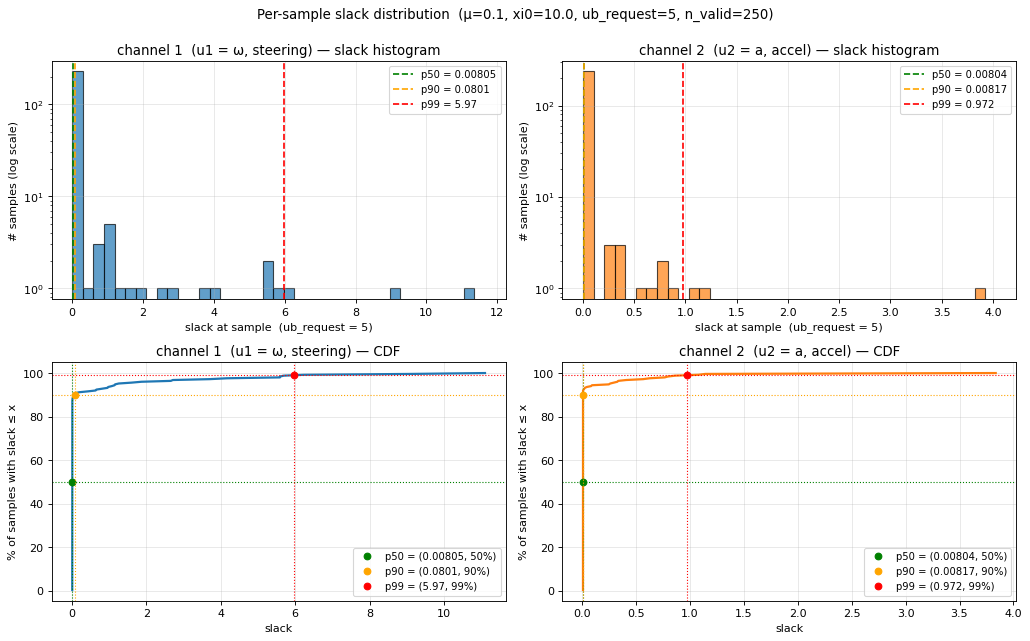

In [ ]:
# Visualization 1 — histogram of per-sample slacks + CDF (log scale to see the long tail)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for j, (s, label, ax_h, ax_c) in enumerate(
    [
        (ch1, "channel 1  (u1 = ω, steering)", axes[0, 0], axes[1, 0]),
        (ch2, "channel 2  (u2 = a, accel)", axes[0, 1], axes[1, 1]),
    ]
):
    # histogram (log y-scale to see the long tail)
    bins = np.linspace(0, s.max() * 1.05, 40)
    ax_h.hist(s, bins=bins, color=f"C{j}", edgecolor="k", alpha=0.7)
    ax_h.set_yscale("log")
    ax_h.set_xlabel(f"slack at sample  (ub_request = {ub_req:g})")
    ax_h.set_ylabel("# samples (log scale)")
    ax_h.set_title(f"{label} — slack histogram")
    for pct, c in [(50, "g"), (90, "orange"), (99, "r")]:
        v = np.percentile(s, pct)
        ax_h.axvline(v, color=c, ls="--", lw=1.5, label=f"p{pct} = {v:.3g}")
    ax_h.legend(fontsize=9)
    ax_h.grid(True, alpha=0.3)

    # empirical CDF
    sorted_s = np.sort(s)
    cdf = np.arange(1, len(s) + 1) / len(s) * 100
    ax_c.plot(sorted_s, cdf, "-", color=f"C{j}", lw=2)
    ax_c.set_xlabel("slack")
    ax_c.set_ylabel("% of samples with slack ≤ x")
    ax_c.set_title(f"{label} — CDF")
    for pct, c in [(50, "g"), (90, "orange"), (99, "r")]:
        v = np.percentile(s, pct)
        ax_c.axhline(pct, color=c, ls=":", lw=1)
        ax_c.axvline(v, color=c, ls=":", lw=1)
        ax_c.plot([v], [pct], "o", color=c, ms=6, label=f"p{pct} = ({v:.3g}, {pct}%)")
    ax_c.legend(loc="lower right", fontsize=9)
    ax_c.grid(True, alpha=0.3)

fig.suptitle(
    f"Per-sample slack distribution  (μ={PARAMS['mu']}, xi0={PARAMS['xi0']}, "
    f"ub_request={ub_req:g}, n_valid={PARAMS['n_valid_samples']})",
    y=1.00,
    fontsize=12,
)
fig.tight_layout()
plt.show()

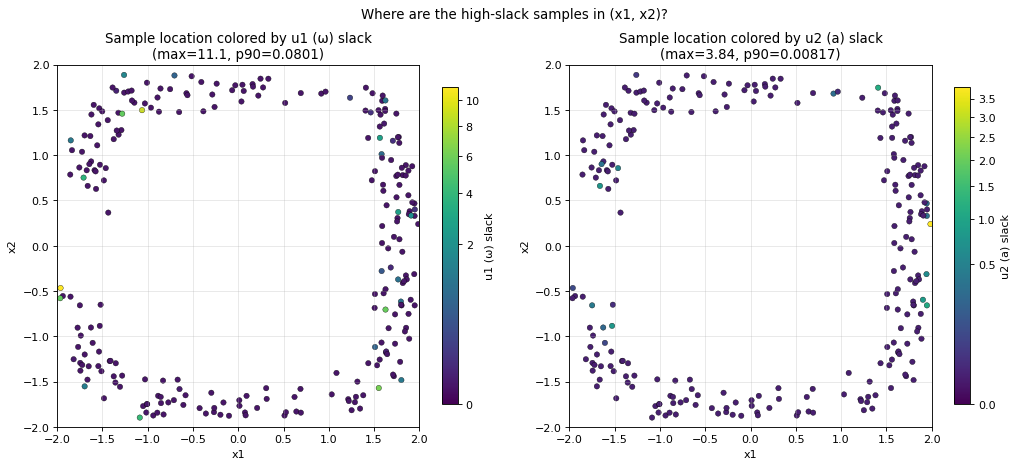

In [ ]:
# Visualization 2 — spatial location of high-slack samples on (x1, x2),
# colored by max slack across channels.
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for j, (s, ax, label) in enumerate(
    [(ch1, axes[0], "u1 (ω) slack"), (ch2, axes[1], "u2 (a) slack")]
):
    # use power-norm coloring to compress the heavy tail
    from matplotlib.colors import PowerNorm

    norm = PowerNorm(gamma=0.4, vmin=0, vmax=max(s.max(), 1e-6))
    sc = ax.scatter(
        df_slack["x1"],
        df_slack["x2"],
        c=s,
        s=24,
        cmap="viridis",
        norm=norm,
        edgecolor="k",
        linewidth=0.3,
    )
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(
        f"Sample location colored by {label}\n"
        f"(max={s.max():.3g}, p90={np.percentile(s,90):.3g})"
    )
    ax.set_aspect("equal", "box")
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    plt.colorbar(sc, ax=ax, label=label, shrink=0.85)
    ax.grid(True, alpha=0.3)

fig.suptitle("Where are the high-slack samples in (x1, x2)?", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

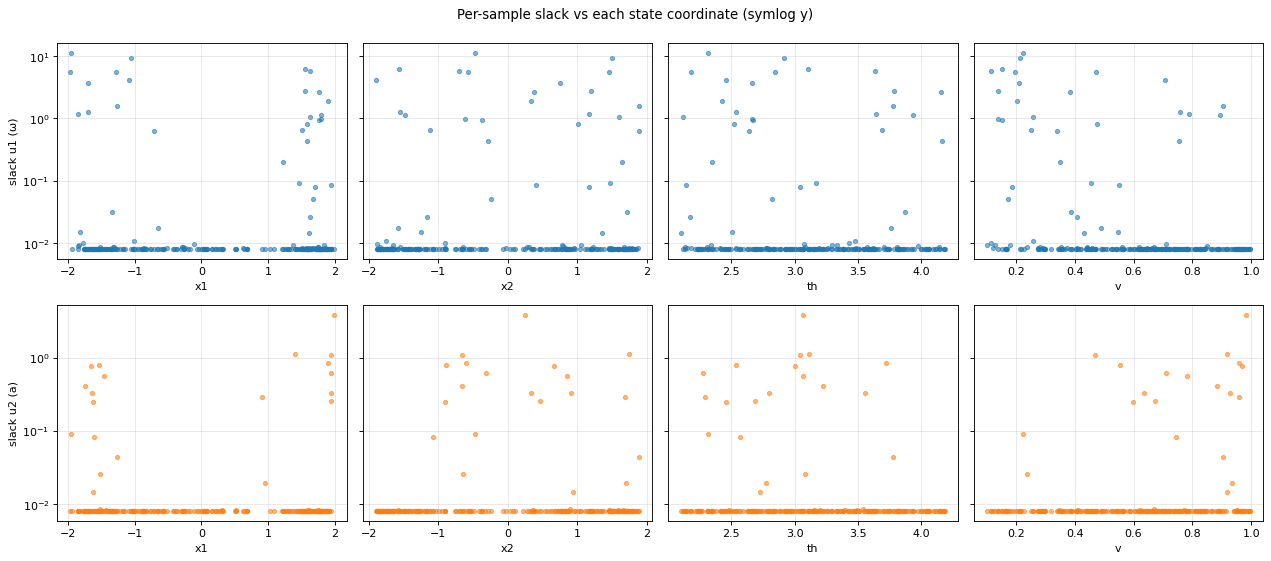

In [ ]:
# Visualization 3 — slack vs each state coordinate (which dimensions drive the difficulty?)
state_cols = ["x1", "x2", "th", "v"]
fig, axes = plt.subplots(
    2, len(state_cols), figsize=(4.0 * len(state_cols), 7.0), sharey="row"
)

for col_j, sname in enumerate(state_cols):
    for row_i, (s, ch_label, color) in enumerate(
        [(ch1, "u1 (ω)", "C0"), (ch2, "u2 (a)", "C1")]
    ):
        ax = axes[row_i, col_j]
        ax.scatter(df_slack[sname], s, s=14, alpha=0.55, color=color)
        ax.set_xlabel(sname)
        if col_j == 0:
            ax.set_ylabel(f"slack {ch_label}")
        ax.set_yscale("symlog", linthresh=1e-3)
        ax.grid(True, alpha=0.3)

fig.suptitle(
    "Per-sample slack vs each state coordinate (symlog y)", y=1.00, fontsize=12
)
fig.tight_layout()
plt.show()

## §5 — Pick `ub_demo` and the kept subset

Using `PARAMS["coverage_pct"]` (default 80), set

$$
\mathrm{ub\_demo}_i \;=\; \mathrm{ub} + p_q\bigl(s_{\cdot,i}^\star\bigr), \quad q = \texttt{coverage\_pct},
$$

and define the _kept_ subset

$$
\mathcal{J}_{\text{kept}} \;=\; \bigl\{\, j \in \{1,\ldots,N\} \;:\; s_{j,1}^\star \le p_q(s_{\cdot,1}^\star)
\,\text{ and }\, s_{j,2}^\star \le p_q(s_{\cdot,2}^\star)\,\bigr\}.
$$

By construction, the original controller already satisfies
$|u_i^\star(x_j)| \le \mathrm{ub\_demo}_i$ at every $j \in \mathcal{J}_{\text{kept}}$ — so
the next (hard) SOP can enforce these bounds without slack at the kept samples.

We then write `kept_samples_*.csv` for §6 to load.


In [ ]:
q = PARAMS["coverage_pct"]
p_q_1 = float(np.percentile(ch1, q))
p_q_2 = float(np.percentile(ch2, q))
ub_demo_1 = float(PARAMS["ub"] + p_q_1)
ub_demo_2 = float(PARAMS["ub"] + p_q_2)
keep_mask = (ch1 <= p_q_1) & (ch2 <= p_q_2)
n_keep = int(keep_mask.sum())

print(f"coverage q  = {q}%")
print(f"p_q(slack u1) = {p_q_1:.4g}  →  ub_demo_1 = {ub_demo_1:.4g}")
print(f"p_q(slack u2) = {p_q_2:.4g}  →  ub_demo_2 = {ub_demo_2:.4g}")
print(f"kept    = {n_keep:>4d} / {len(df_slack)}  ({100*n_keep/len(df_slack):.1f}%)")
print(f"dropped = {len(df_slack)-n_keep:>4d} / {len(df_slack)}  (hard outliers)")

# write kept samples for the hard SOP MATLAB driver
PATH_KEPT = os.path.join(DATA_LOCAL, f"kept_samples_{SUFFIX}_q{q}.csv")
df_kept = df_slack.loc[keep_mask, ["sample_idx", "x1", "x2", "th", "v"]].reset_index(
    drop=True
)
df_kept.to_csv(PATH_KEPT, index=False)
print(f"\nwrote {os.path.basename(PATH_KEPT)} ({len(df_kept)} rows)")

coverage q  = 80%
p_q(slack u1) = 0.008268  →  ub_demo_1 = 5.008
p_q(slack u2) = 0.008071  →  ub_demo_2 = 5.008
kept    =  156 / 250  (62.4%)
dropped =   94 / 250  (hard outliers)

wrote kept_samples_0p1_10_5_q80.csv (156 rows)


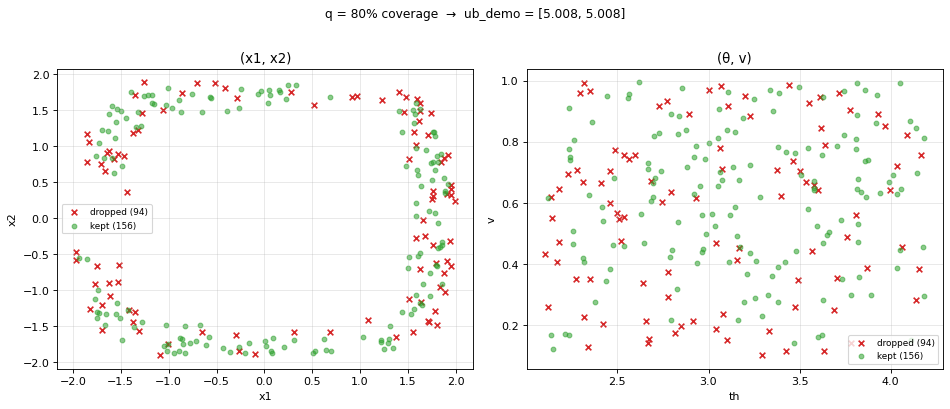

In [ ]:
# Visualize kept vs dropped on (x1, x2) and (θ, v).
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (title, xcol, ycol) in zip(
    axes, [("(x1, x2)", "x1", "x2"), ("(θ, v)", "th", "v")]
):
    ax.scatter(
        df_slack.loc[~keep_mask, xcol],
        df_slack.loc[~keep_mask, ycol],
        s=26,
        color="C3",
        marker="x",
        label=f"dropped ({(~keep_mask).sum()})",
    )
    ax.scatter(
        df_slack.loc[keep_mask, xcol],
        df_slack.loc[keep_mask, ycol],
        s=18,
        color="C2",
        alpha=0.55,
        label=f"kept ({keep_mask.sum()})",
    )
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)
fig.suptitle(
    f"q = {PARAMS['coverage_pct']}% coverage  →  ub_demo = "
    f"[{ub_demo_1:.4g}, {ub_demo_2:.4g}]",
    y=1.02,
    fontsize=11,
)
fig.tight_layout()
plt.show()

## §6 — Constrained controller from HARD SOP on the kept subset

With $(\mathrm{ub\_demo}, \mathcal{J}_{\text{kept}})$ fixed, solve the **hard-bound** SOP
(no per-sample slack variables, no objective on slack):

$$
\begin{aligned}
\min_{k_1, \delta, s_1, s_2}\;\; & \delta \\
\text{s.t.}\;\;
& \nabla_y \psi \cdot k_1 - \lambda\,\psi + \delta - s_1\psi - s_2 g_T \in \Sigma[y] && \text{(y-space CBF descent)} \\
& M_j(k_1) \succeq 0 && j \in \mathcal{J}_{\text{kept}} \quad \text{(certificate LMI)} \\
& -\mathrm{ub\_demo}_i \;\le\; u_i(x_j) \;\le\; +\mathrm{ub\_demo}_i && j \in \mathcal{J}_{\text{kept}},\; i = 1,\ldots,m \\
& \delta \ge 0,\;\; s_1, s_2 \in \Sigma[y]
\end{aligned}
$$

The input-bound constraint is **two-sided** (per channel $i$, per kept sample $j$): the
solver `solve_k1_controller_sop_hard.m` adds **two separate SOS scalar inequalities**

$$
u_i(x_j) - (-\mathrm{ub\_demo}_i) \;\ge\; 0
\quad\text{and}\quad
\mathrm{ub\_demo}_i - u_i(x_j) \;\ge\; 0,
$$

so both the lower and the upper bound on $u_i(x_j)$ are enforced. We pass
$\mathrm{lb}=-\mathrm{ub\_demo},\; \mathrm{ub}=+\mathrm{ub\_demo}$ as a per-channel vector
(`lb = [-ub1; -ub2], ub = [ub1; ub2]` in the driver).

MATLAB driver: `scripts/dubins_demo/matlab/build_dubins_demo_subset_hard.m`. The driver
reports `feasible = true / false` based on Mosek `pinf`/`dinf`; the notebook proceeds only
on feasibility.

The unconstrained controller (§4's `mod_unc`) is the **vanilla** $k_1$ at the same $\lambda$
— that's our "no slack, no input constraints" baseline.


In [ ]:
HARD_TAG = f"hard_q{PARAMS['coverage_pct']}"
HARD_SUFFIX = f"{HARD_TAG}_{_fmt(PARAMS['mu'])}_{_fmt(PARAMS['xi0'])}_{_fmt(ub_demo_1)}x{_fmt(ub_demo_2)}"
PATH_CON_HARD = os.path.join(DATA_LOCAL, f"controller_con_{HARD_SUFFIX}.py")
PATH_META_HARD = os.path.join(DATA_LOCAL, f"meta_{HARD_SUFFIX}.csv")

env_hard = {
    "MU": PARAMS["mu"],
    "XI0": PARAMS["xi0"],
    "UB1": ub_demo_1,
    "UB2": ub_demo_2,
    "SAMPLES_CSV": PATH_KEPT,
    "TAG": HARD_TAG,
}

REGENERATE_HARD = False
need_hard = REGENERATE_HARD or not all(
    os.path.exists(p) for p in (PATH_CON_HARD, PATH_META_HARD)
)
# also check cached meta against current PARAMS
if not need_hard:
    cached = pd.read_csv(PATH_META_HARD).iloc[0]
    for ckey, want, tol in [
        ("mu", PARAMS["mu"], 1e-9),
        ("xi0", PARAMS["xi0"], 1e-9),
        ("ub1", ub_demo_1, 1e-9),
        ("ub2", ub_demo_2, 1e-9),
        ("n_valid_samples", n_keep, 0.5),
    ]:
        if ckey not in cached.index or abs(float(cached[ckey]) - float(want)) > tol:
            need_hard = True
            print(
                f"  cache miss: meta {ckey}={cached.get(ckey, '?')} vs wanted {want} → regenerate"
            )
            break

if need_hard:
    print("running build_dubins_demo_subset_hard.m ...")
    out = run_matlab(
        "build_dubins_demo_subset_hard", env_overrides=env_hard, regenerate=True
    )
    print("\n".join(out.strip().splitlines()[-10:]))
else:
    print("hard SOP outputs cached and PARAMS match — skipping MATLAB.")

meta_hard = pd.read_csv(PATH_META_HARD).iloc[0]
print("\nhard SOP meta:")
print(meta_hard.to_string())

if int(meta_hard["feasible"]) == 0:
    raise RuntimeError(
        "Hard SOP infeasible — cannot proceed to §7. "
        "Relax ub_demo (e.g. raise coverage_pct) or drop more outliers."
    )

mod_con_hard = load_controller(PATH_CON_HARD)
u_con_hard_funcs = [lambdify_state(e) for e in mod_con_hard.u_opt]
V_con_hard_func = lambdify_state(mod_con_hard.certificate_opt)
print("\nloaded controller_con_hard, lambdified.")

hard SOP outputs cached and PARAMS match — skipping MATLAB.

hard SOP meta:
mu                   0.100000
xi0                 10.000000
ub1                  5.008268
ub2                  5.008071
n_valid_samples    156.000000
feasible             1.000000
lambda              10.000000
delta              112.532017
pinf                 0.000000
dinf                 0.000000
feasratio           -0.960344

loaded controller_con_hard, lambdified.


## §7 — Output-space comparison on $X_S \setminus X_T$

Densely sample states $x$ satisfying

$$
\psi(h(x)) \ge 0 \quad \text{(in safe set)} \quad\text{and}\quad g_T(h(x)) \ge 0 \quad \text{(outside target)}.
$$

For each such state, evaluate $u_{\text{con}}(x)$ (hard SOP, §6) and $u_{\text{unc}}(x)$
(vanilla, §4) and project the **difference** onto output space $y = h(x) = (x_1, x_2)$:

$$
\Delta_i(y) \;=\; u_i^{\text{con}}(x) - u_i^{\text{unc}}(x), \qquad i = 1, 2.
$$

We then visualize:

- the **distribution of $\Delta_i$** (histogram per channel),
- a **spatial scatter** on $(x_1, x_2)$ colored by $|\Delta_i|$ (where in output space do the
  two controllers disagree most?).


In [ ]:
# Iteratively sample inside X_S \ X_T (safe ≥ 0 AND target ≥ 0). Target a fixed dense count.
N_TARGET = 4000  # number of dense states in X_S \ X_T (tunable)
bmin = np.array([-2.0, -2.0, 2 * np.pi / 3, 0.1])
bmax = np.array([2.0, 2.0, 4 * np.pi / 3, 1.0])
rng_dense = np.random.default_rng(2026)


# Pull the y-space safe/target polynomials from the (already-loaded) modules' free symbols.
# Easier: define them in Python directly (must match build_dubins_demo.m).
def safe_fn(x1v, x2v, thv, vv):
    y1, y2 = x1v, x2v  # h(x) = (x1, x2) for Dubins
    h_raw = -(y1**4 + y2**4 - 16) * (y1**4 + y2**4 - 4)
    target = (y2) ** 2 + ((y1 + 1.7) / 0.5) ** 2 - 0.4
    alpha = 1e-3 * (-target + 300)
    return alpha * h_raw


def target_fn(x1v, x2v, thv, vv):
    y1, y2 = x1v, x2v
    return (y2) ** 2 + ((y1 + 1.7) / 0.5) ** 2 - 0.4


accumulated = []
total_tried = 0
batch = max(N_TARGET * 4, 4000)
while sum(len(b) for b in accumulated) < N_TARGET and total_tried < 50 * N_TARGET:
    cand = bmin + (bmax - bmin) * rng_dense.random((batch, 4))
    sv = safe_fn(cand[:, 0], cand[:, 1], cand[:, 2], cand[:, 3])
    tv = target_fn(cand[:, 0], cand[:, 1], cand[:, 2], cand[:, 3])
    accepted = cand[(sv >= 0) & (tv >= 0)]
    accumulated.append(accepted)
    total_tried += batch
dense = np.concatenate(accumulated)[:N_TARGET]
print(
    f"dense sampling: collected {len(dense)} states in X_S \\ X_T (tried {total_tried}, "
    f"yield {100*len(dense)/total_tried:.1f}%)"
)

# Evaluate both controllers
xc = [dense[:, i] for i in range(4)]
u1_con_h = u_con_hard_funcs[0](*xc)
u2_con_h = u_con_hard_funcs[1](*xc)
u1_unc = u_unc_funcs[0](*xc)
u2_unc = u_unc_funcs[1](*xc)

d1 = u1_con_h - u1_unc
d2 = u2_con_h - u2_unc
print(
    f"\nΔ on channel 1 (ω):  min={d1.min():.4g}, max={d1.max():.4g}, "
    f"mean={d1.mean():.4g}, std={d1.std():.4g}, |Δ|_max={np.max(np.abs(d1)):.4g}"
)
print(
    f"Δ on channel 2 (a):  min={d2.min():.4g}, max={d2.max():.4g}, "
    f"mean={d2.mean():.4g}, std={d2.std():.4g}, |Δ|_max={np.max(np.abs(d2)):.4g}"
)

dense sampling: collected 4000 states in X_S \ X_T (tried 16000, yield 25.0%)

Δ on channel 1 (ω):  min=-80.6, max=75.32, mean=0.3224, std=11.62, |Δ|_max=80.6
Δ on channel 2 (a):  min=-7.14, max=9.494, mean=3.301, std=2.446, |Δ|_max=9.494


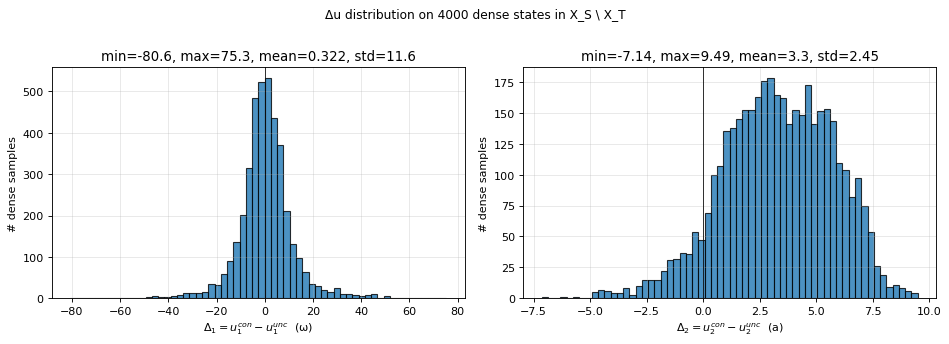

In [ ]:
# Histograms of the per-channel differences
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, (d, lbl) in zip(
    axes,
    [
        (d1, r"$\Delta_1 = u_1^{con} - u_1^{unc}$  (ω)"),
        (d2, r"$\Delta_2 = u_2^{con} - u_2^{unc}$  (a)"),
    ],
):
    ax.hist(d, bins=60, alpha=0.8, edgecolor="k")
    ax.axvline(0, color="k", lw=0.7)
    ax.set_xlabel(lbl)
    ax.set_ylabel("# dense samples")
    ax.set_title(
        f"min={d.min():.3g}, max={d.max():.3g}, mean={d.mean():.3g}, std={d.std():.3g}"
    )
    ax.grid(True, alpha=0.3)
fig.suptitle(
    f"Δu distribution on {len(dense)} dense states in X_S \\ X_T", y=1.02, fontsize=11
)
fig.tight_layout()
plt.show()

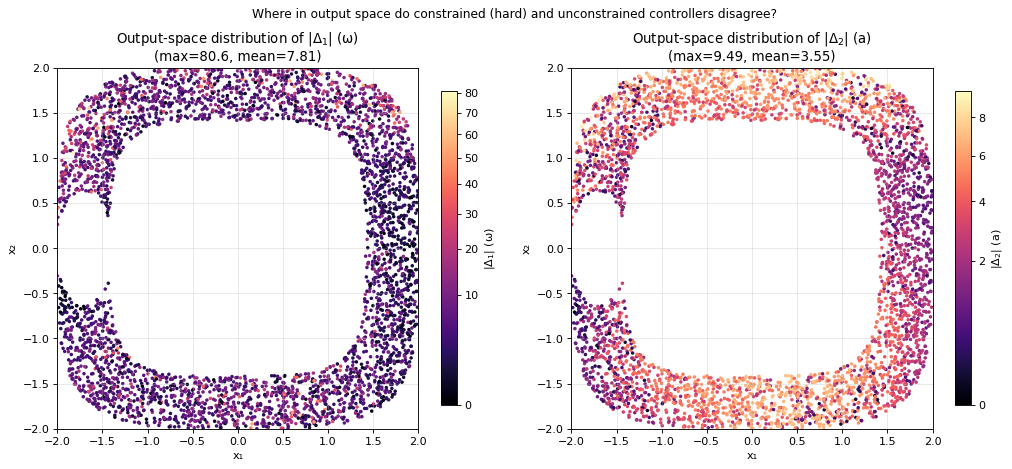

In [ ]:
# Spatial visualization in output space y = (x1, x2).
# For each dense state, plot a dot at (x1, x2) colored by |Δ_i|.
from matplotlib.colors import PowerNorm

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, (d, lbl) in zip(
    axes, [(np.abs(d1), r"$|\Delta_1|$ (ω)"), (np.abs(d2), r"$|\Delta_2|$ (a)")]
):
    norm = PowerNorm(gamma=0.5, vmin=0, vmax=max(d.max(), 1e-6))
    sc = ax.scatter(
        dense[:, 0], dense[:, 1], c=d, s=10, cmap="magma", norm=norm, edgecolor="none"
    )
    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")
    ax.set_title(
        f"Output-space distribution of {lbl}\n(max={d.max():.3g}, mean={d.mean():.3g})"
    )
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_aspect("equal", "box")
    plt.colorbar(sc, ax=ax, shrink=0.85, label=lbl)
    ax.grid(True, alpha=0.3)
fig.suptitle(
    "Where in output space do constrained (hard) and unconstrained controllers disagree?",
    y=1.02,
    fontsize=11,
)
fig.tight_layout()
plt.show()

### §7.2 — RA-set membership of the dense samples (output-space 4-color overlay)

For each dense sample $x \in X_S \setminus X_T$, classify it by the **sign of both certificates**:

|                           | $V_{\text{con}}(x) \ge 0$                              | $V_{\text{con}}(x) < 0$                    |
| ------------------------- | ------------------------------------------------------ | ------------------------------------------ |
| $V_{\text{unc}}(x) \ge 0$ | 🟩 both certify (common RA)                            | 🟦 only unc certifies (constraint removes) |
| $V_{\text{unc}}(x) < 0$   | 🟥 only con certifies (unexpected, SOS shape mismatch) | ⬜ neither certifies                       |

Then project the categorisation onto the output plane $(x_1, x_2)$.


In [ ]:
# Evaluate both certificates on the dense samples
Vcon_d = V_con_hard_func(*xc)
Vunc_d = V_unc_func(*xc)

both = (Vcon_d >= 0) & (Vunc_d >= 0)
only_un = (Vcon_d < 0) & (Vunc_d >= 0)
only_co = (Vcon_d >= 0) & (Vunc_d < 0)
neither = (Vcon_d < 0) & (Vunc_d < 0)
n = len(dense)

cat = np.zeros(n, dtype=int)
cat[both] = 1  # green
cat[only_un] = 2  # blue
cat[only_co] = 3  # red
# neither stays 0 → white/gray

print(f"RA-set membership of the {n} dense samples in X_S \\ X_T:")
print(f"  both certify (green)         = {both.sum():>5d}   ({100*both.mean():.2f}%)")
print(
    f"  only unc certifies (blue)    = {only_un.sum():>5d}   ({100*only_un.mean():.2f}%)  [paper-style: constraint removes these]"
)
print(
    f"  only con certifies (red)     = {only_co.sum():>5d}   ({100*only_co.mean():.2f}%)  [SOS shape mismatch]"
)
print(
    f"  neither (gray)               = {neither.sum():>5d}   ({100*neither.mean():.2f}%)"
)
print()
if both.sum() > 0:
    print(
        f"  subset_rate     = |con ∩ unc| / |con| = "
        f"{both.sum() / max((Vcon_d >= 0).sum(), 1):.4f}    [≈ 1 if con ⊆ unc]"
    )
if (Vunc_d >= 0).sum() > 0:
    print(
        f"  removed_frac    = |unc \\ con| / |unc| = "
        f"{only_un.sum() / (Vunc_d >= 0).sum():.4f}    [> 0 if constraint shrinks]"
    )
if (Vcon_d >= 0).sum() > 0:
    print(
        f"  unexpected_frac = |con \\ unc| / |con| = "
        f"{only_co.sum() / (Vcon_d >= 0).sum():.4f}    [≈ 0 if con ⊆ unc]"
    )

RA-set membership of the 4000 dense samples in X_S \ X_T:
  both certify (green)         =  2238   (55.95%)
  only unc certifies (blue)    =    55   (1.38%)  [paper-style: constraint removes these]
  only con certifies (red)     =  1321   (33.02%)  [SOS shape mismatch]
  neither (gray)               =   386   (9.65%)

  subset_rate     = |con ∩ unc| / |con| = 0.6288    [≈ 1 if con ⊆ unc]
  removed_frac    = |unc \ con| / |unc| = 0.0240    [> 0 if constraint shrinks]
  unexpected_frac = |con \ unc| / |con| = 0.3712    [≈ 0 if con ⊆ unc]


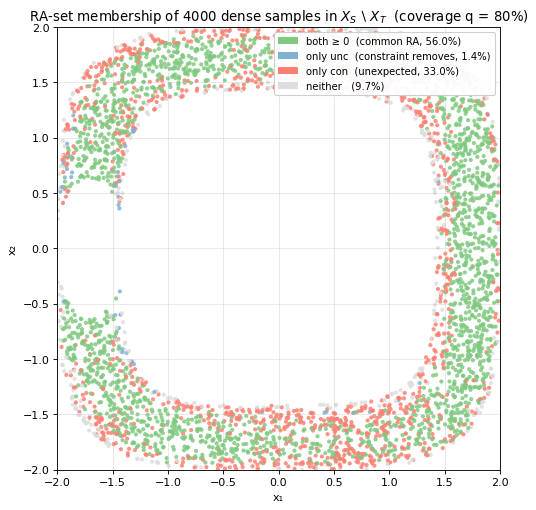

In [ ]:
# Output-space scatter, color-coded by category.
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

cmap4 = ListedColormap(
    ["#dddddd", "#7fc97f", "#80b1d3", "#fb8072"]
)  # gray, green, blue, red
fig, ax = plt.subplots(figsize=(7.5, 6.5))
sc = ax.scatter(
    dense[:, 0],
    dense[:, 1],
    c=cat,
    s=14,
    cmap=cmap4,
    vmin=0,
    vmax=3,
    edgecolor="none",
    alpha=0.85,
)
ax.set_xlabel("x₁")
ax.set_ylabel("x₂")
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_aspect("equal", "box")
ax.set_title(
    f"RA-set membership of {n} dense samples in $X_S \\setminus X_T$  "
    f"(coverage q = {PARAMS['coverage_pct']}%)"
)
ax.grid(True, alpha=0.3)

legend_patches = [
    Patch(facecolor="#7fc97f", label=f"both ≥ 0  (common RA, {100*both.mean():.1f}%)"),
    Patch(
        facecolor="#80b1d3",
        label=f"only unc  (constraint removes, {100*only_un.mean():.1f}%)",
    ),
    Patch(
        facecolor="#fb8072", label=f"only con  (unexpected, {100*only_co.mean():.1f}%)"
    ),
    Patch(facecolor="#dddddd", label=f"neither   ({100*neither.mean():.1f}%)"),
]
ax.legend(handles=legend_patches, loc="upper right", fontsize=9, framealpha=0.95)
fig.tight_layout()
plt.show()

## §8 — Closed-loop trajectories from a common-RA initial condition far from the target

Pick an $x_0 \in \{V_{\text{unc}} \ge 0\} \cap \{V_{\text{con}} \ge 0\}$ — a state in the
**green** region (both controllers' certificates validate it) — and choose one **far from
$X_T$** so the trajectory has substantial control activity before reaching the target.

Expected pattern: **both** controllers should reach the target (both certify $x_0$); we then
compare the resulting input magnitudes against $\mathrm{ub\_demo}$ to see which one stays
within the bound.


In [ ]:
from systems import dubins_system, make_callables, simulate

# Candidates: green region (both V ≥ 0), non-singular v, far from X_T
target_d = target_fn(dense[:, 0], dense[:, 1], dense[:, 2], dense[:, 3])
idx_green = np.where(both & (dense[:, 3] >= 0.3) & (target_d > 0.5))[0]
print(f"# green-region dense candidates (v≥0.3, far from X_T): {len(idx_green)}")
if len(idx_green) == 0:
    raise RuntimeError("No suitable green candidate — relax the filters.")

# Pre-screen at x_0 (no integration yet): keep candidates where
#   |u_con(x_0)| ≤ ub_demo   on BOTH channels (con already respects bound at start)
#   |u_unc(x_0)| > ub_demo   on at LEAST ONE channel (unc already violates at start)
xa = dense[idx_green]
u1c0 = u_con_hard_funcs[0](xa[:, 0], xa[:, 1], xa[:, 2], xa[:, 3])
u2c0 = u_con_hard_funcs[1](xa[:, 0], xa[:, 1], xa[:, 2], xa[:, 3])
u1u0 = u_unc_funcs[0](xa[:, 0], xa[:, 1], xa[:, 2], xa[:, 3])
u2u0 = u_unc_funcs[1](xa[:, 0], xa[:, 1], xa[:, 2], xa[:, 3])

con_ok_at_x0 = (np.abs(u1c0) <= ub_demo_1) & (np.abs(u2c0) <= ub_demo_2)
unc_violates_at_x0 = (np.abs(u1u0) > ub_demo_1) | (np.abs(u2u0) > ub_demo_2)
mask_x0 = con_ok_at_x0 & unc_violates_at_x0
idx_x0 = idx_green[mask_x0]
print(f"# of those where |u_con(x₀)| ≤ ub_demo AND unc violates at x₀: {len(idx_x0)}")
if len(idx_x0) == 0:
    raise RuntimeError(
        "No candidate satisfies the strict pre-screen at x₀ — relax filters."
    )

# Rank: prefer LARGE distance from target, well inside RA, large gap between unc's |u| at x_0
# and ub_demo (so unc violation is dramatic).
xa2 = dense[idx_x0]
violation_margin = np.maximum(
    np.abs(u_unc_funcs[0](xa2[:, 0], xa2[:, 1], xa2[:, 2], xa2[:, 3])) - ub_demo_1,
    np.abs(u_unc_funcs[1](xa2[:, 0], xa2[:, 1], xa2[:, 2], xa2[:, 3])) - ub_demo_2,
)
score_arr = (
    target_d[idx_x0] * 1.5
    + 0.5 * np.minimum(Vunc_d[idx_x0], Vcon_d[idx_x0])
    + 0.3 * np.log(np.maximum(violation_margin, 1e-3))
)
order = np.argsort(-score_arr)
top_candidates = [int(idx_x0[k]) for k in order[:20]]
print(
    f"top candidate target_d values:  {[f'{target_d[i]:.3g}' for i in top_candidates[:5]]}"
)
print(
    f"top candidate unc violation @ x₀: {[f'{violation_margin[order[k]]:.3g}' for k in range(min(5, len(order)))]}"
)

# Try each candidate; pick the first one where both controllers' simulations are well-behaved.
sys_d = dubins_system()
cb_con = make_callables(sys_d, mod_con_hard.u_opt)
cb_unc = make_callables(sys_d, mod_unc.u_opt)

CAP = 1000.0
# Pick the first candidate where:
#   - both simulations are well-behaved (finite, max|u| < CAP)
#   - both reach the target
#   - CON stays safe throughout the trajectory
#   - CON respects ub_demo on BOTH channels for the whole trajectory (≥ 95% of timesteps)
#   - UNC exceeds ub_demo on at least one channel (peak > 1.2 × ub_demo)
chosen = None
chosen_summary = None
for cand_i in top_candidates:
    x0 = dense[cand_i].copy()
    r_con = simulate(sys_d, cb_con, x0, max_step=PARAMS["sim_max_step"])
    r_unc = simulate(sys_d, cb_unc, x0, max_step=PARAMS["sim_max_step"])
    if r_con["U"].size == 0 or r_unc["U"].size == 0:
        continue
    if not (np.isfinite(r_con["max_abs_u"]).all() and r_con["max_abs_u"].max() < CAP):
        continue
    if not (np.isfinite(r_unc["max_abs_u"]).all() and r_unc["max_abs_u"].max() < CAP):
        continue
    if not (r_con["reached"] and r_unc["reached"]):
        continue
    if not r_con["stayed_safe"]:
        continue
    absU_c = np.abs(r_con["U"])
    absU_u = np.abs(r_unc["U"])
    frac_c1 = float(np.mean(absU_c[0] <= ub_demo_1))
    frac_c2 = float(np.mean(absU_c[1] <= ub_demo_2))
    if frac_c1 < 0.95 or frac_c2 < 0.95:
        continue
    unc_violates = (absU_u[0].max() > 1.2 * ub_demo_1) or (
        absU_u[1].max() > 1.2 * ub_demo_2
    )
    if not unc_violates:
        continue
    chosen = (cand_i, x0, r_con, r_unc)
    chosen_summary = dict(
        frac_c1=frac_c1,
        frac_c2=frac_c2,
        unc_peak1=float(absU_u[0].max()),
        unc_peak2=float(absU_u[1].max()),
    )
    break

# Fallback: if no candidate meets all conditions, relax the "con respects both" requirement
# and pick the best one in the top list by con-respect fraction.
if chosen is None:
    print(
        "⚠ strict criteria not met by any candidate — falling back to best-effort pick."
    )
    best_score, best = -np.inf, None
    for cand_i in top_candidates:
        x0 = dense[cand_i].copy()
        r_con = simulate(sys_d, cb_con, x0, max_step=PARAMS["sim_max_step"])
        r_unc = simulate(sys_d, cb_unc, x0, max_step=PARAMS["sim_max_step"])
        if r_con["U"].size == 0 or r_unc["U"].size == 0:
            continue
        if not (
            np.isfinite(r_con["max_abs_u"]).all() and r_con["max_abs_u"].max() < CAP
        ):
            continue
        if not (
            np.isfinite(r_unc["max_abs_u"]).all() and r_unc["max_abs_u"].max() < CAP
        ):
            continue
        absU_c = np.abs(r_con["U"])
        absU_u = np.abs(r_unc["U"])
        f1 = float(np.mean(absU_c[0] <= ub_demo_1))
        f2 = float(np.mean(absU_c[1] <= ub_demo_2))
        # score: con respect rate − unc respect rate (gap), tie-break on stayed_safe
        score = (f1 + f2) - (
            np.mean(absU_u[0] <= ub_demo_1) + np.mean(absU_u[1] <= ub_demo_2)
        )
        if r_con["stayed_safe"]:
            score += 0.5
        if score > best_score:
            best_score, best = score, (cand_i, x0, r_con, r_unc, f1, f2)
    if best is None:
        raise RuntimeError("No candidate produced any well-behaved trajectories.")
    cand_i, x0, r_con, r_unc, f1, f2 = best
    chosen = (cand_i, x0, r_con, r_unc)
    chosen_summary = dict(frac_c1=f1, frac_c2=f2)

cand_i, x0, r_con, r_unc = chosen
print(f"\nChosen x0 (sample index {cand_i}):")
print(f"  x0 = ({x0[0]:.4g}, {x0[1]:.4g}, {x0[2]:.4g}, {x0[3]:.4g})  → (x1, x2, θ, v)")
print(f"  V_unc(x0)   = {Vunc_d[cand_i]:.4g}  (≥ 0, inside unc RA)")
print(f"  V_con(x0)   = {Vcon_d[cand_i]:.4g}  (≥ 0, inside con RA)")
print(f"  target(h(x0)) = {target_d[cand_i]:.4g}  (>> 0  ⇒  far from X_T)")


def summarize(name, r, ub_pair):
    n_steps = len(r["t"])
    absU = np.abs(r["U"])
    # Where does the trajectory go in v?  The FL region the controller was synthesized in
    # is v ∈ [0.1, 1.0]; if the trajectory drifts outside it, the controller is extrapolating
    # and may behave wildly (1/v factor in the Dubins control law).
    v_min = float(r["X"][:, 3].min()) if n_steps else float("nan")
    v_max = float(r["X"][:, 3].max()) if n_steps else float("nan")
    # State at peak |u₁|
    if absU.size:
        i1 = int(np.argmax(absU[0]))
        x_at_max_u1 = r["X"][i1]
        t_at_max_u1 = float(r["t"][i1])
    else:
        x_at_max_u1 = np.array([np.nan] * 4)
        t_at_max_u1 = float("nan")
    return dict(
        name=name,
        reached=r["reached"],
        stayed_safe=r["stayed_safe"],
        n_steps=n_steps,
        v_min=v_min,
        v_max=v_max,
        max_u1=float(np.max(absU[0])) if absU.size else float("nan"),
        max_u2=float(np.max(absU[1])) if absU.size else float("nan"),
        excess_u1=float(np.max(absU[0]) - ub_pair[0]) if absU.size else float("nan"),
        excess_u2=float(np.max(absU[1]) - ub_pair[1]) if absU.size else float("nan"),
        frac_u1_resp=(
            float(np.mean(absU[0] <= ub_pair[0])) if absU.size else float("nan")
        ),
        frac_u2_resp=(
            float(np.mean(absU[1] <= ub_pair[1])) if absU.size else float("nan")
        ),
        t_at_max_u1=t_at_max_u1,
        v_at_max_u1=float(x_at_max_u1[3]),
    )


ub_pair = (ub_demo_1, ub_demo_2)
s_con = summarize("con (hard)", r_con, ub_pair)
s_unc = summarize("unc (vanilla)", r_unc, ub_pair)

print(f"\n{'metric':>32s}   {'con (hard)':>12s}   {'unc (vanilla)':>14s}")
for k, label in [
    ("reached", "reached target"),
    ("stayed_safe", "stayed in safe set"),
    ("n_steps", "# integration steps"),
    ("v_min", "min v(t)  (FL region: v ≥ 0.1)"),
    ("v_max", "max v(t)  (FL region: v ≤ 1.0)"),
    ("max_u1", f"max |u₁(t)|  (ub_demo_1 = {ub_demo_1:.4g})"),
    ("max_u2", f"max |u₂(t)|  (ub_demo_2 = {ub_demo_2:.4g})"),
    ("excess_u1", "max |u₁| − ub_demo_1"),
    ("excess_u2", "max |u₂| − ub_demo_2"),
    ("frac_u1_resp", "% time |u₁| ≤ ub_demo_1"),
    ("frac_u2_resp", "% time |u₂| ≤ ub_demo_2"),
    ("v_at_max_u1", "v at the moment of max |u₁|"),
    ("t_at_max_u1", "t at the moment of max |u₁|"),
]:
    v_c = s_con[k]
    v_u = s_unc[k]
    if isinstance(v_c, bool):
        print(f"  {label:>30s}   {str(v_c):>12s}   {str(v_u):>14s}")
    elif isinstance(v_c, (int, np.integer)):
        print(f"  {label:>30s}   {v_c:>12d}   {v_u:>14d}")
    elif k.startswith("frac_"):
        print(f"  {label:>30s}   {100*v_c:>11.2f}%   {100*v_u:>13.2f}%")
    else:
        print(f"  {label:>30s}   {v_c:>12.4g}   {v_u:>14.4g}")

# green-region dense candidates (v≥0.3, far from X_T): 1733
# of those where |u_con(x₀)| ≤ ub_demo AND unc violates at x₀: 704
top candidate target_d values:  ['51.9', '51.7', '53', '51', '52']
top candidate unc violation @ x₀: ['2.32', '2.29', '0.578', '2.04', '0.117']
⚠ strict criteria not met by any candidate — falling back to best-effort pick.

Chosen x0 (sample index 1075):
  x0 = (1.849, 1.002, 3.069, 0.3912)  → (x1, x2, θ, v)
  V_unc(x0)   = 4.551  (≥ 0, inside unc RA)
  V_con(x0)   = 6.896  (≥ 0, inside con RA)
  target(h(x0)) = 50.99  (>> 0  ⇒  far from X_T)

                          metric     con (hard)    unc (vanilla)
                  reached target           True             True
              stayed in safe set          False            False
             # integration steps          13581             9406
  min v(t)  (FL region: v ≥ 0.1)         0.1849           0.3912
  max v(t)  (FL region: v ≤ 1.0)          23.02            45.08
  max |u₁(t)|  (ub_demo_1 = 5.008) 

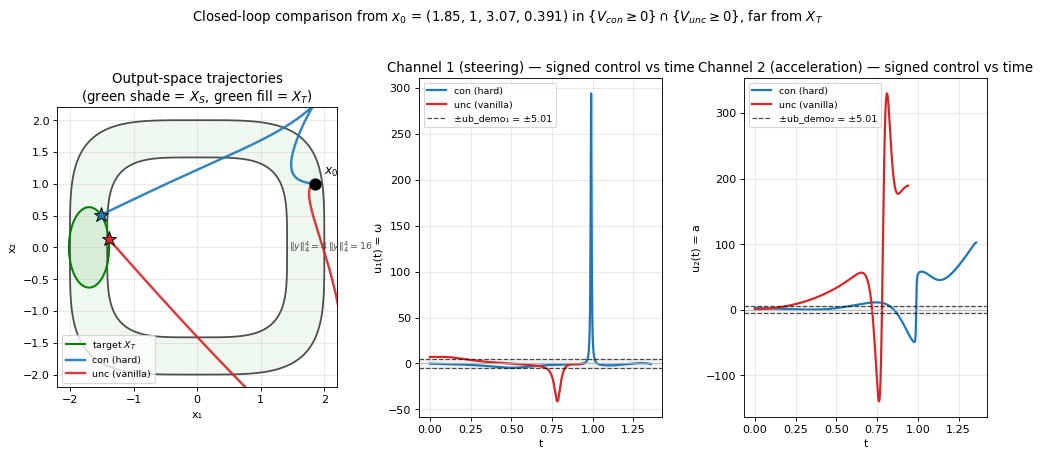

In [ ]:
# Three-panel plot: output-space trajectories with safe set + per-channel signed u(t)
fig = plt.figure(figsize=(15, 5.5))
gs = fig.add_gridspec(1, 3, width_ratios=[1.15, 1.0, 1.0], wspace=0.32)

# ── Panel 1: (x1, x2) with safe set, target, both trajectories ────────────────
ax = fig.add_subplot(gs[0, 0])

# Safe set:  ψ(y) = 1e-3·(-target_y + 300) * (-(y1⁴+y2⁴-16)(y1⁴+y2⁴-4)) ≥ 0
# The (-target+300) factor is always positive on the plotting window, so the safe-set
# boundary collapses to the annulus  4 ≤ y1⁴ + y2⁴ ≤ 16.
yy1 = np.linspace(-2.2, 2.2, 600)
yy2 = np.linspace(-2.2, 2.2, 600)
YY1, YY2 = np.meshgrid(yy1, yy2)
R4 = YY1**4 + YY2**4
ax.contour(YY1, YY2, R4, levels=[16], colors="0.3", linewidths=1.6, linestyles="-")
ax.contour(YY1, YY2, R4, levels=[4], colors="0.3", linewidths=1.6, linestyles="-")
# Shade the safe set lightly
safe_mask = (R4 >= 4) & (R4 <= 16)
ax.contourf(
    YY1, YY2, safe_mask.astype(float), levels=[0.5, 1.5], colors=["#e6f5e6"], alpha=0.65
)

# Target boundary  ((y1+1.7)/0.5)² + y2² = 0.4
tt = np.linspace(0, 2 * np.pi, 200)
ax.plot(
    -1.7 + 0.5 * np.sqrt(0.4) * np.cos(tt),
    np.sqrt(0.4) * np.sin(tt),
    "g-",
    lw=1.8,
    label="target $X_T$",
)
ax.fill(
    -1.7 + 0.5 * np.sqrt(0.4) * np.cos(tt),
    np.sqrt(0.4) * np.sin(tt),
    color="#c8e6c8",
    alpha=0.6,
)

# Trajectories
for name, r, color in [("con (hard)", r_con, "C0"), ("unc (vanilla)", r_unc, "C3")]:
    if len(r["X"]) > 0:
        ax.plot(r["X"][:, 0], r["X"][:, 1], color=color, lw=2.2, alpha=0.9, label=name)
        if r["reached"]:
            ax.plot(
                r["X"][-1, 0],
                r["X"][-1, 1],
                "*",
                color=color,
                ms=14,
                markeredgecolor="k",
                markeredgewidth=0.8,
            )
# x0 marker
ax.plot(x0[0], x0[1], "o", color="k", ms=10, zorder=5)
ax.annotate(
    "$x_0$", (x0[0], x0[1]), xytext=(8, 8), textcoords="offset points", fontsize=11
)

# Safe-set boundary labels
ax.text(
    2.05, 0.0, "$\\|y\\|_4^4 = 16$", color="0.3", fontsize=8.5, ha="left", va="center"
)
ax.text(
    1.45, 0.0, "$\\|y\\|_4^4 = 4$", color="0.3", fontsize=8.5, ha="left", va="center"
)

ax.set_xlabel("x₁")
ax.set_ylabel("x₂")
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
ax.set_aspect("equal", "box")
ax.set_title("Output-space trajectories\n(green shade = $X_S$, green fill = $X_T$)")
ax.legend(loc="lower left", fontsize=8.5)
ax.grid(True, alpha=0.3)

# ── Panel 2: signed u₁(t) (ω) vs time, with ±ub_demo_1 overlay ────────────────
ax = fig.add_subplot(gs[0, 1])
for name, r, color in [("con (hard)", r_con, "C0"), ("unc (vanilla)", r_unc, "C3")]:
    if r["U"].size > 0:
        ax.plot(r["t"], r["U"][0], color=color, lw=2.0, label=name)
ax.axhline(
    ub_demo_1,
    color="k",
    ls="--",
    lw=1.1,
    alpha=0.7,
    label=f"±ub_demo₁ = ±{ub_demo_1:.3g}",
)
ax.axhline(-ub_demo_1, color="k", ls="--", lw=1.1, alpha=0.7)
ax.axhspan(-ub_demo_1, ub_demo_1, color="0.85", alpha=0.35, zorder=0)
ax.axhline(0, color="0.7", lw=0.7)
ax.set_xlabel("t")
ax.set_ylabel("u₁(t) = ω")
ax.set_title("Channel 1 (steering) — signed control vs time")
ax.legend(loc="best", fontsize=8.5)
ax.grid(True, alpha=0.3)

# ── Panel 3: signed u₂(t) (a) vs time, with ±ub_demo_2 overlay ────────────────
ax = fig.add_subplot(gs[0, 2])
for name, r, color in [("con (hard)", r_con, "C0"), ("unc (vanilla)", r_unc, "C3")]:
    if r["U"].size > 0:
        ax.plot(r["t"], r["U"][1], color=color, lw=2.0, label=name)
ax.axhline(
    ub_demo_2,
    color="k",
    ls="--",
    lw=1.1,
    alpha=0.7,
    label=f"±ub_demo₂ = ±{ub_demo_2:.3g}",
)
ax.axhline(-ub_demo_2, color="k", ls="--", lw=1.1, alpha=0.7)
ax.axhspan(-ub_demo_2, ub_demo_2, color="0.85", alpha=0.35, zorder=0)
ax.axhline(0, color="0.7", lw=0.7)
ax.set_xlabel("t")
ax.set_ylabel("u₂(t) = a")
ax.set_title("Channel 2 (acceleration) — signed control vs time")
ax.legend(loc="best", fontsize=8.5)
ax.grid(True, alpha=0.3)

fig.suptitle(
    f"Closed-loop comparison from $x_0$ = ({x0[0]:.3g}, {x0[1]:.3g}, {x0[2]:.3g}, {x0[3]:.3g}) "
    f"in $\\{{V_{{con}}\\geq 0\\}} \\cap \\{{V_{{unc}}\\geq 0\\}}$, far from $X_T$",
    y=1.04,
    fontsize=12,
)
plt.show()